# Comprensión y Análisis Exploratorio de Datos (EDA)
## Christian Pascual

Ojetivo del notebook:
1. Exploración inicial de datos.
2. Limpieza, unificación e imputación de valores nulos.
3. Eliminación de variables irrelevantes.
4. Conversión de tipos de datos a formatos consistentes.
5. Análisis univariado, bivariado y multivariado.
6. Interpretación, reglas de validación y variables derivadas potenciales.

**Variable objetivo:** `Pago_atiempo`

---

1. **Carga de Librerías**

In [1]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype
sns.set(style="whitegrid")

# Función para cargar datos
from cargar_datos import cargar_datos

# Apagamos las warnings
import warnings
warnings.filterwarnings('ignore')

---

2. **Exploración Inicial del Dataset**

In [2]:
# Carga de datos
df = cargar_datos()

# Vista general
display(df.head())

# Dimensiones
print("Shape:", df.shape)

# Tipos de datos
display(df.info())

ruta actual del script: c:\Users\chris\Downloads\DATA SCIENCE\M5\PROYECTO\mlops_pipeline\src
ruta del proyecto: c:\Users\chris\Downloads\DATA SCIENCE\M5\PROYECTO\mlops_pipeline
datos cargados del archivo Excel:
   tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0             7 2024-12-21 11:31:35         3692160.0           10   
1             4 2025-04-22 09:47:35          840000.0            6   
2             9 2026-01-08 12:22:40         5974028.4           10   
3             4 2025-08-04 12:04:10         1671240.0            6   
4             9 2025-04-26 11:24:26         2781636.0           11   

   edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0            42  Independiente          8000000                2500000   
1            60       Empleado          3000000                2000000   
2            36  Independiente          4036000                 829000   
3            48       Empleado          1524547                 498000  

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


Shape: (10763, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 

None

- **Interpretación**

    - El dataset contiene múltiples variables financieras y demográficas.
    - Se identifican variables numéricas, categóricas y temporales.
    - Existen valores nulos que deberán ser tratados.
    - La variable objetivo `Pago_atiempo` será clave para el análisis predictivo.

---

3. **Preparación del Dataset**

In [3]:
def preparar_dataset(df):
    df = df.copy()

    # 1. UNIFICACIÓN DE NULOS

    nulos_reales = ['', ' ', '-', 'nan', 'NaN', 'NULL', 'None', 'N/A']
    df.replace(nulos_reales, np.nan, inplace=True)

    # 2. TARGET

    df = df.dropna(subset=["Pago_atiempo"])
    df["Pago_atiempo"] = df["Pago_atiempo"].astype(int).astype(bool)

    # 3. LIMPIEZA SEMÁNTICA

    if "tendencia_ingresos" in df.columns:
        mapping = {
            'creciente':'Creciente',
            'estable':'Estable',
            'decreciente':'Decreciente'
        }

        df["tendencia_ingresos"] = (
            df["tendencia_ingresos"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(mapping)
        )

    # 4. TIPADO

    # Fechas
    for col in df.columns:
        if "fecha" in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Categóricas
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].astype('category')

    # Numéricas
    num_cols = df.select_dtypes(include=['int64','float64']).columns
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

    # 5. IMPUTADO DE NULOS

    # CATEGÓRICAS → "Desconocido"
    cat_cols = df.select_dtypes(include='category').columns.tolist()

    for col in cat_cols:
        if df[col].isnull().any():
            if "Desconocido" not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories(["Desconocido"])
            df[col] = df[col].fillna("Desconocido")
            print(f"{col}: imputado como 'Desconocido'")


    # NUMÉRICAS → Dependiendo del tipo elige su imputación
    num_cols = df.select_dtypes(include=['int64','float64']).columns

    for col in num_cols:
        
        if df[col].isnull().any():
            
            col_lower = col.lower()
            skewness = df[col].skew()
            perc_zeros = (df[col] == 0).mean()
            
            
            # 1. VARIABLES DE AUSENCIA REAL (muchos ceros o nombre indicativo)
            if (
                perc_zeros > 0.6 
                or any(keyword in col_lower for keyword in ['mora','huella','conteo','cantidad','num','cant'])
            ):
                df[col] = df[col].fillna(0)
                print(f"{col}: imputado con 0 (detectado como ausencia real)")
            
            
            # 2. VARIABLES TIPO SCORE / RIESGO (usar percentil bajo + flag)
            elif any(keyword in col_lower for keyword in ['score','puntaje','rating']):
                
                df[f'{col}_sin_info'] = df[col].isnull().astype(int)
                val = df[col].quantile(0.05)
                df[col] = df[col].fillna(val)
                
                print(f"{col}: imputado con P5 ({val:.2f}) + flag (score detectado)")
            
            
            # 3. VARIABLES MUY SESGADAS (skew alto → mediana)
            elif abs(skewness) > 1:
                
                med = df[col].median()
                df[col] = df[col].fillna(med)
                
                print(f"{col}: imputado con mediana ({med:.2f}) (alta asimetría)")
            
            
            # 4. VARIABLES MÁS NORMALES → media
            else:
                
                mean = df[col].mean()
                df[col] = df[col].fillna(mean)
                
                print(f"{col}: imputado con media ({mean:.2f})")
    return df

df = preparar_dataset(df)

df.head()

tendencia_ingresos: imputado como 'Desconocido'
puntaje_datacredito: imputado con P5 (710.00) + flag (score detectado)
saldo_mora: imputado con 0 (detectado como ausencia real)
saldo_total: imputado con mediana (16178.00) (alta asimetría)
saldo_principal: imputado con mediana (14442.50) (alta asimetría)
saldo_mora_codeudor: imputado con 0 (detectado como ausencia real)
promedio_ingresos_datacredito: imputado con mediana (1204496.00) (alta asimetría)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,puntaje_datacredito_sin_info
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,True,0
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,True,0
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,18702.0,18702.0,0.0,3,0,0,1204496.0,Desconocido,False,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,True,0
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,True,0


- **Interpretación**

    - Se unificaron múltiples representaciones de nulos.
    - Se aseguró que el target sea booleano.
    - Se corrigieron errores en variables categóricas clave.
    - Se tiparon correctamente variables numéricas, categóricas y fechas.
    - Se imputaron los nulos en las variables correspondientes con la siguiente clasificación:
        Enfoque dinámico basado en:

        - Distribución de los datos (skewness)
        - Proporción de ceros
        - Semántica del nombre de la variable

        Estrategias aplicadas:

        - Variables con alta proporción de ceros → imputación con 0
        - Variables tipo score → imputación con percentil bajo + variable indicadora
        - Variables sesgadas → mediana
        - Variables aproximadamente normales → media

        Este enfoque permite generalizar el tratamiento de nulos sin depender de reglas manuales.


---

4. **Calidad de Datos**

- Analisis de Nulos

In [4]:
# Nulos
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

tabla_nulos = pd.DataFrame({
    "nulos": nulos,
    "%": porcentaje
}).sort_values("%", ascending=False)

display(tabla_nulos)

# Duplicados
print("Duplicados:", df.duplicated().sum())

,nulos,%
tipo_credito,0,0.0
fecha_prestamo,0,0.0
capital_prestado,0,0.0
plazo_meses,0,0.0
edad_cliente,0,0.0
tipo_laboral,0,0.0
salario_cliente,0,0.0
total_otros_prestamos,0,0.0
cuota_pactada,0,0.0
puntaje,0,0.0


Duplicados: 0


- **Interpretación**

    - Algunas variables presentan alto porcentaje de nulos → candidatas a imputación o eliminación.
    - No hay duplicados significativos (o son mínimos).

---

5. **Caracterización de Variables**

In [5]:
def caracterizar(df):
    resumen = []

    for col in df.columns:
        n = df[col].nunique()

        if is_bool_dtype(df[col]):
            tipo = "Dicotómica"
        elif is_datetime64_any_dtype(df[col]):
            tipo = "Temporal"
        elif is_numeric_dtype(df[col]):
            entero = df[col].dropna().mod(1).eq(0).all()
            tipo = "Numérica Discreta" if entero and n < 20 else "Numérica Continua"
        else:
            tipo = "Categórica"

        resumen.append({
            "columna": col,
            "tipo": tipo,
            "n_unicos": n,
            "%_nulos": round(df[col].isnull().mean()*100,2)
        })

    return pd.DataFrame(resumen)

display(caracterizar(df))

,columna,tipo,n_unicos,%_nulos
0,tipo_credito,Numérica Discreta,6,0.0
1,fecha_prestamo,Temporal,10758,0.0
2,capital_prestado,Numérica Continua,7306,0.0
3,plazo_meses,Numérica Discreta,18,0.0
4,edad_cliente,Numérica Continua,54,0.0
5,tipo_laboral,Categórica,2,0.0
6,salario_cliente,Numérica Continua,1385,0.0
7,total_otros_prestamos,Numérica Continua,1538,0.0
8,cuota_pactada,Numérica Continua,9836,0.0
9,puntaje,Numérica Continua,248,0.0


---

6. **Análisis Univariado**

- **Variables Númericas:**

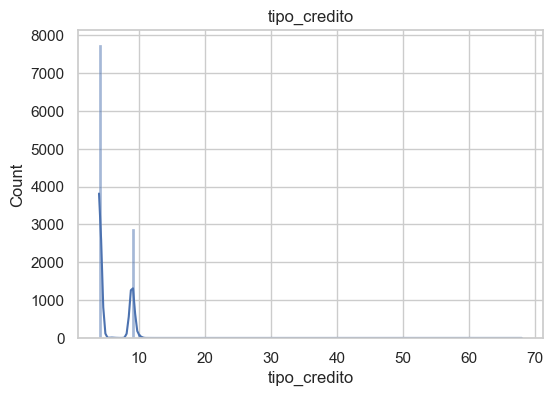

count    10763.000000
mean         5.411131
std          2.338279
min          4.000000
25%          4.000000
50%          4.000000
75%          9.000000
max         68.000000
Name: tipo_credito, dtype: float64
Skew: 2.6720741021812078 Kurtosis: 46.4642600149523


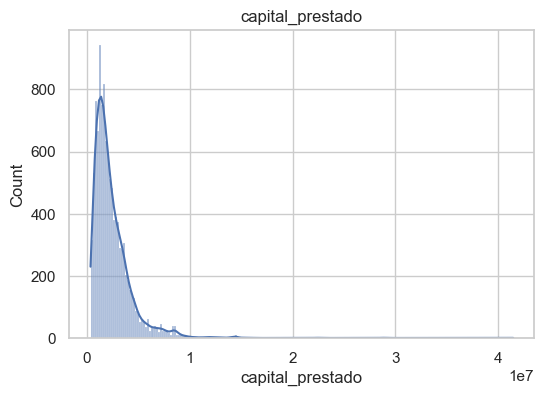

count    1.076300e+04
mean     2.434315e+06
std      1.909643e+06
min      3.600000e+05
25%      1.224831e+06
50%      1.921920e+06
75%      3.084840e+06
max      4.144415e+07
Name: capital_prestado, dtype: float64
Skew: 3.7238840473433266 Kurtosis: 35.31809201334321


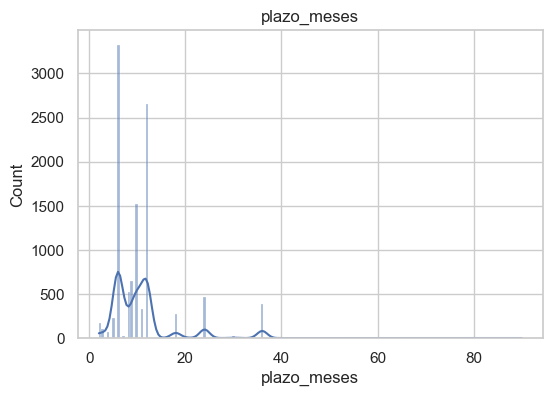

count    10763.000000
mean        10.575583
std          6.632082
min          2.000000
25%          6.000000
50%         10.000000
75%         12.000000
max         90.000000
Name: plazo_meses, dtype: float64
Skew: 2.459690979130265 Kurtosis: 7.7801206468075765


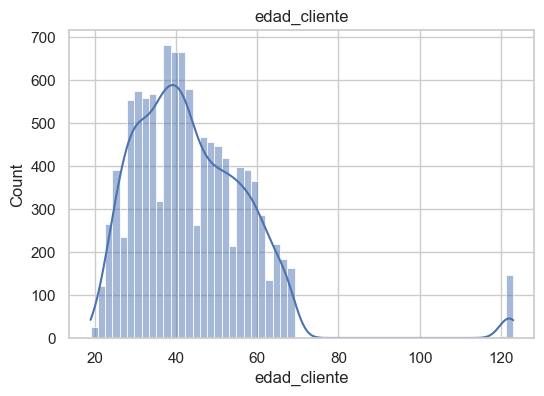

count    10763.000000
mean        43.948620
std         15.060877
min         19.000000
25%         33.000000
50%         42.000000
75%         53.000000
max        123.000000
Name: edad_cliente, dtype: float64
Skew: 1.9343986145489613 Kurtosis: 7.868935590502208


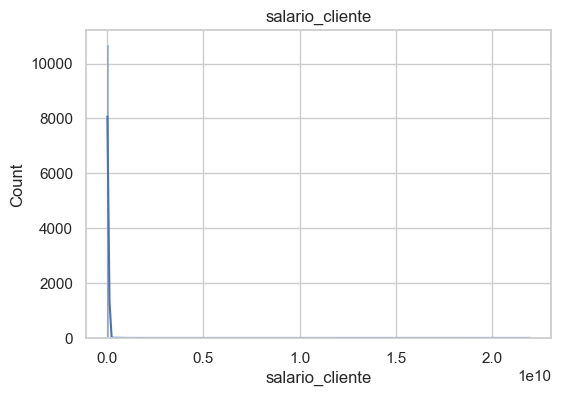

count    1.076300e+04
mean     1.721643e+07
std      3.554767e+08
min      0.000000e+00
25%      2.000000e+06
50%      3.000000e+06
75%      4.875808e+06
max      2.200000e+10
Name: salario_cliente, dtype: float64
Skew: 43.776663892299965 Kurtosis: 2211.2301200244087


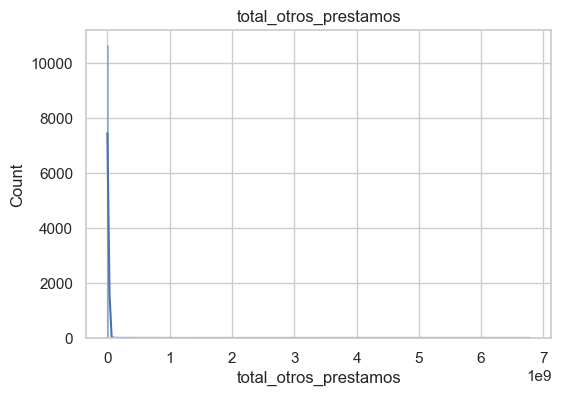

count    1.076300e+04
mean     6.238870e+06
std      1.184183e+08
min      0.000000e+00
25%      5.000000e+05
50%      1.000000e+06
75%      2.000000e+06
max      6.787675e+09
Name: total_otros_prestamos, dtype: float64
Skew: 38.46388619150297 Kurtosis: 1719.280870807578


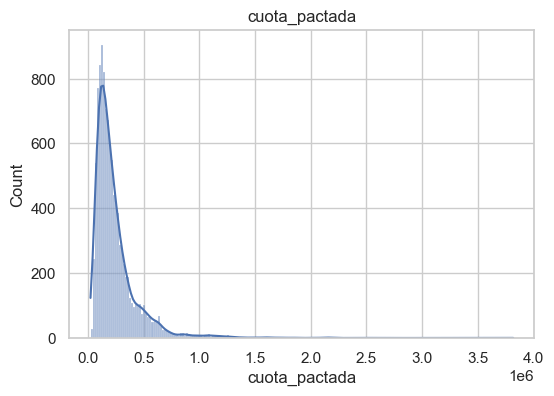

count    1.076300e+04
mean     2.436174e+05
std      2.104937e+05
min      2.394400e+04
25%      1.210415e+05
50%      1.828630e+05
75%      2.878335e+05
max      3.816752e+06
Name: cuota_pactada, dtype: float64
Skew: 3.793301066470034 Kurtosis: 26.65075701177427


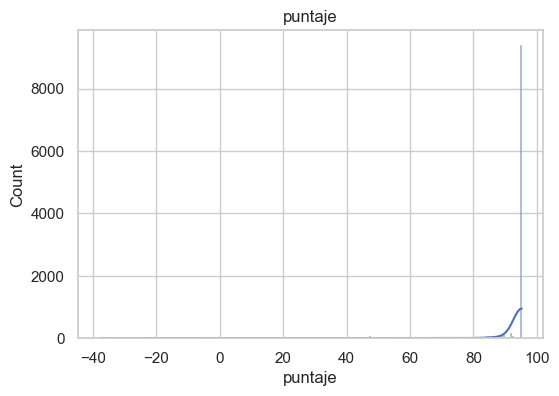

count    10763.000000
mean        91.170036
std         16.465441
min        -38.009990
25%         95.227787
50%         95.227787
75%         95.227787
max         95.227787
Name: puntaje, dtype: float64
Skew: -4.865607388749235 Kurtosis: 24.081010843265627


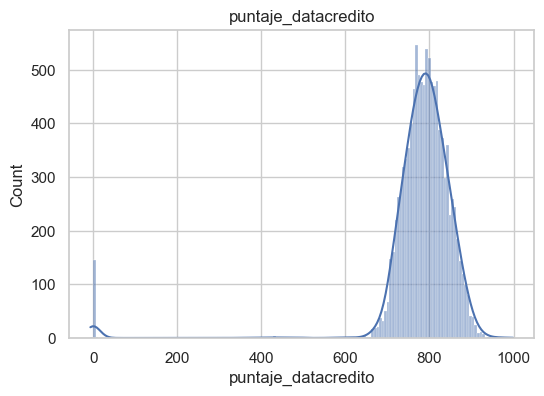

count    10763.000000
mean       780.751370
std        104.862107
min         -7.000000
25%        757.000000
50%        791.000000
75%        825.000000
max        999.000000
Name: puntaje_datacredito, dtype: float64
Skew: -5.6429782016797 Kurtosis: 39.43151293444097


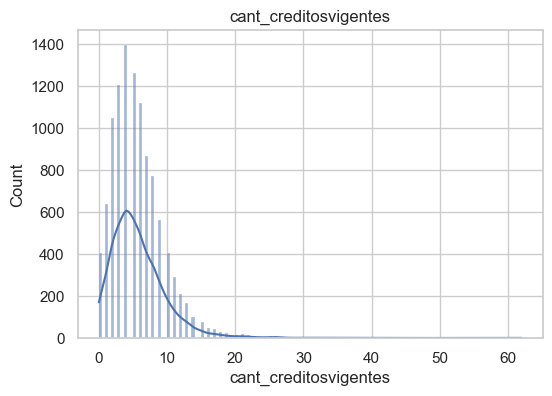

count    10763.000000
mean         5.726749
std          3.977162
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         62.000000
Name: cant_creditosvigentes, dtype: float64
Skew: 1.7977378502721395 Kurtosis: 8.623346326463976


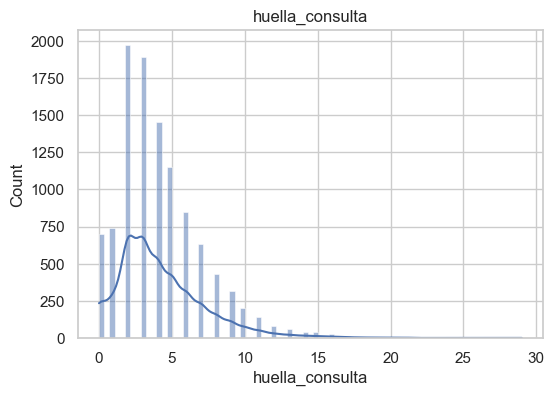

count    10763.000000
mean         4.228561
std          3.064683
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: huella_consulta, dtype: float64
Skew: 1.487101835960047 Kurtosis: 3.9989838055497224


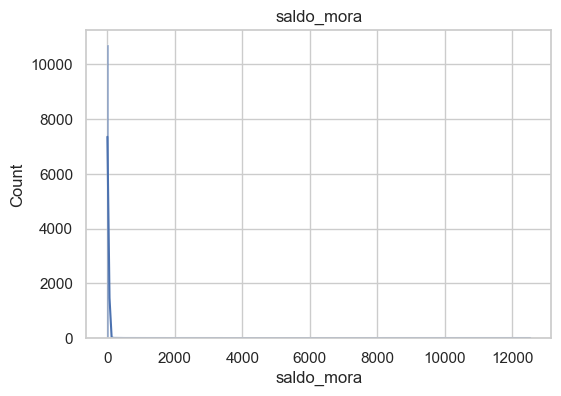

count    10763.000000
mean         7.633745
std        224.313390
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      12534.000000
Name: saldo_mora, dtype: float64
Skew: 40.8660929049415 Kurtosis: 1872.9074630486236


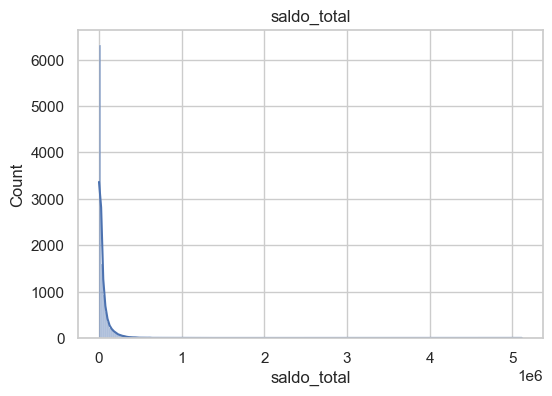

count    1.076300e+04
mean     4.550607e+04
std      1.055567e+05
min      0.000000e+00
25%      3.025000e+03
50%      1.617800e+04
75%      5.215600e+04
max      5.116066e+06
Name: saldo_total, dtype: float64
Skew: 20.322910615339627 Kurtosis: 799.3197979566283


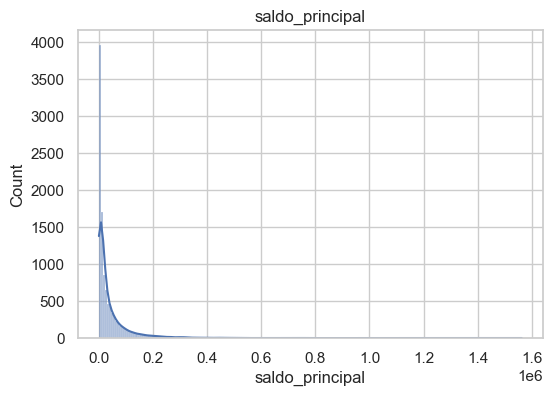

count    1.076300e+04
mean     3.937144e+04
std      7.006271e+04
min      0.000000e+00
25%      2.999000e+03
50%      1.444250e+04
75%      4.529700e+04
max      1.562285e+06
Name: saldo_principal, dtype: float64
Skew: 5.149592850916674 Kurtosis: 52.908166552000715


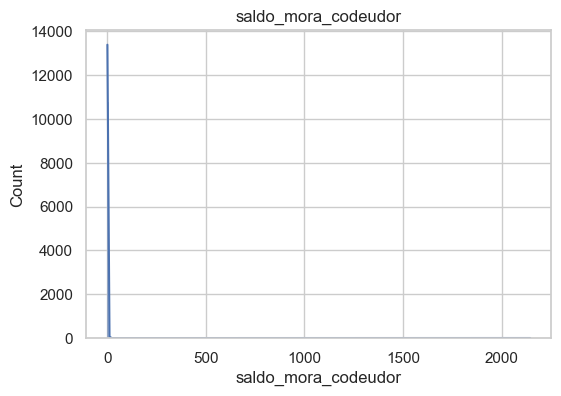

count    10763.000000
mean         0.245749
std         21.167764
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2145.000000
Name: saldo_mora_codeudor, dtype: float64
Skew: 97.68679023484783 Kurtosis: 9818.042754793742


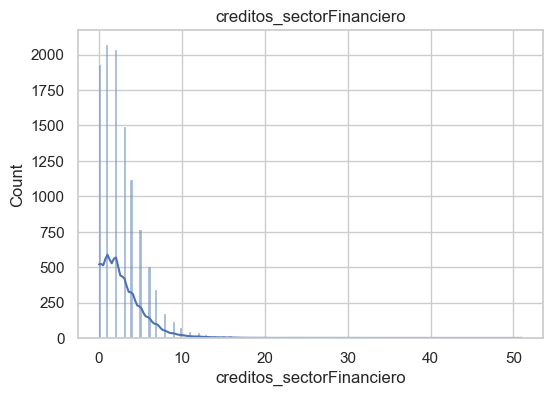

count    10763.000000
mean         2.779987
std          2.748807
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         51.000000
Name: creditos_sectorFinanciero, dtype: float64
Skew: 2.703071227846393 Kurtosis: 19.441771232966072


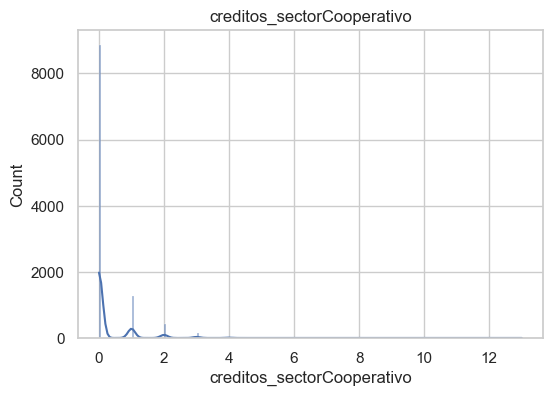

count    10763.000000
mean         0.269813
std          0.716471
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.000000
Name: creditos_sectorCooperativo, dtype: float64
Skew: 4.218667197548848 Kurtosis: 29.351455191451368


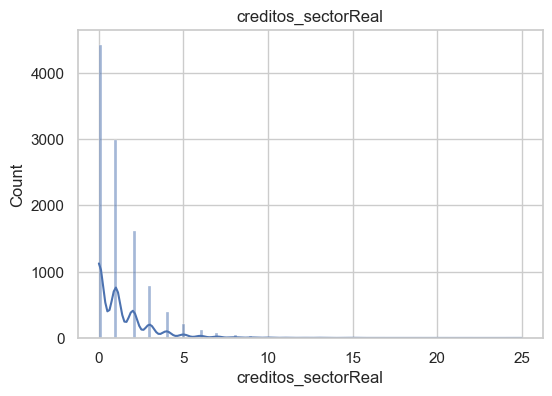

count    10763.000000
mean         1.302704
std          1.824430
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         25.000000
Name: creditos_sectorReal, dtype: float64
Skew: 3.1648659934286245 Kurtosis: 18.18720840358743


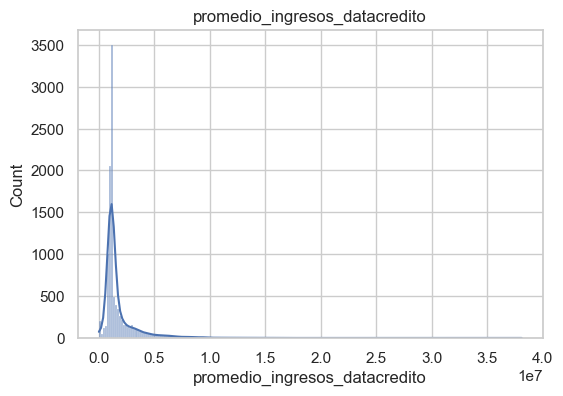

count    1.076300e+04
mean     1.787194e+06
std      1.863501e+06
min      0.000000e+00
25%      9.618850e+05
50%      1.204496e+06
75%      1.705770e+06
max      3.810658e+07
Name: promedio_ingresos_datacredito, dtype: float64
Skew: 5.075177908373536 Kurtosis: 44.91627227800985


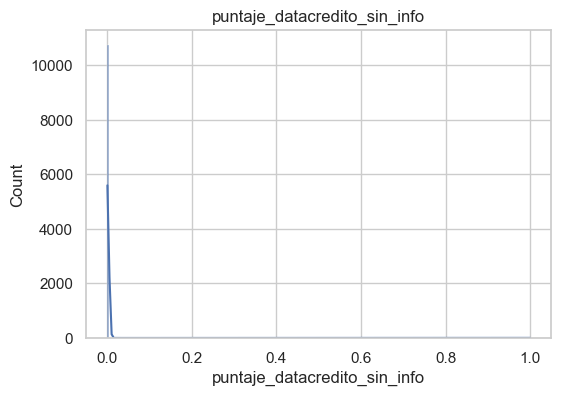

count    10763.000000
mean         0.000557
std          0.023605
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: puntaje_datacredito_sin_info, dtype: float64
Skew: 42.324144158740424 Kurtosis: 1789.665737644264


In [6]:
numericas = df.select_dtypes(include=['int64','float64']).columns

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

    print(df[col].describe())
    print("Skew:", df[col].skew(), "Kurtosis:", df[col].kurt())


- **Interpretación**

    - Muchas variables financieras presentan **alta asimetría (skew)**.
    - Se observan **outliers importantes** (común en datos financieros).
    - Algunas variables podrían requerir transformación logarítmica.

- **Variables Categóricas:**

tipo_laboral
Empleado         62.752021
Independiente    37.247979
Name: proportion, dtype: float64

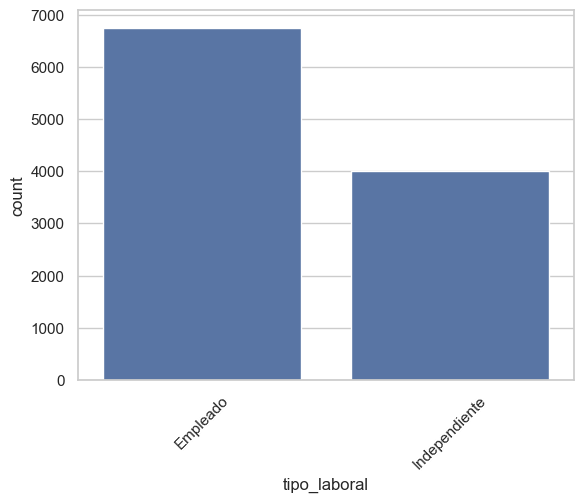

tendencia_ingresos
Creciente      49.187030
Desconocido    27.780359
Decreciente    11.994797
Estable        11.037815
Name: proportion, dtype: float64

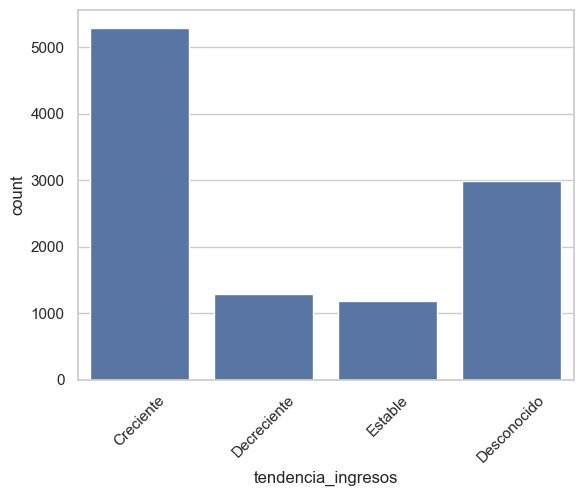

In [7]:
categoricas = df.select_dtypes(include='category').columns

for col in categoricas:
    display(df[col].value_counts(normalize=True)*100)

    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

- **Interpretación**

    - Algunas categorías dominan la distribución.
    - Categorías poco frecuentes podrían afectar el modelo.

---

7. **Análisis Bivariado** 

- Variable Target (`Pago_atiempo`)

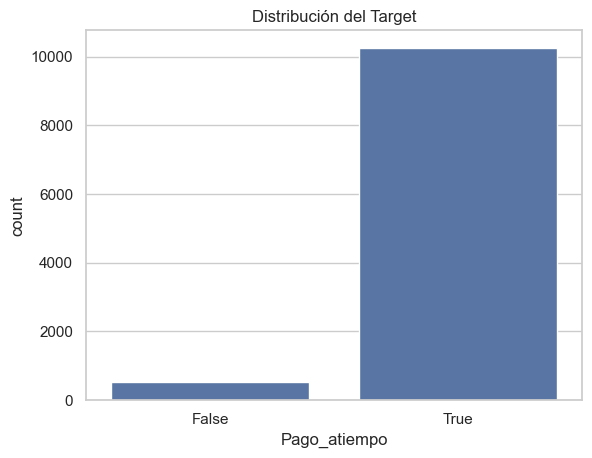

Pago_atiempo
True     95.252253
False     4.747747
Name: proportion, dtype: float64

In [51]:
sns.countplot(x="Pago_atiempo", data=df)
plt.title("Distribución del Target")
plt.show()

df["Pago_atiempo"].value_counts(normalize=True)*100

- **Interpretación**

    - Existe **desbalance de clases** (muy importante).
    - Esto impactará el modelado → se requerirá técnica de balanceo.    

- **Variables numéricas vs target**:

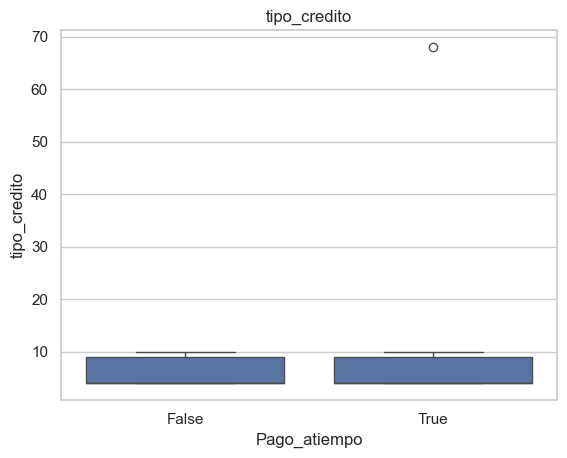

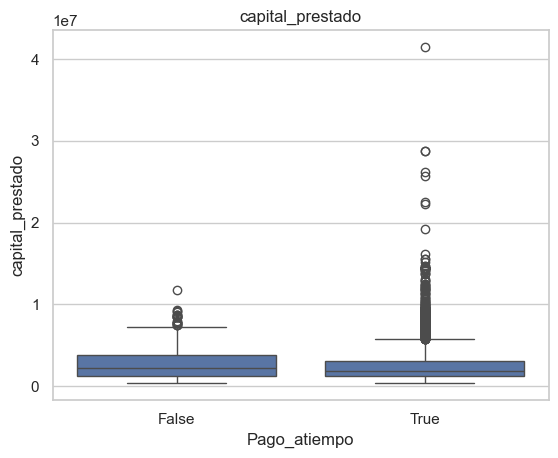

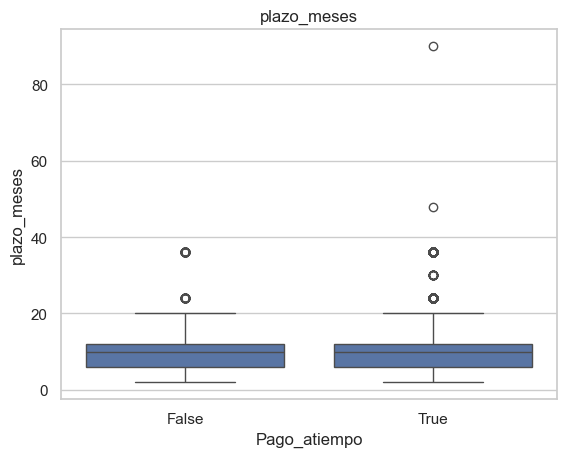

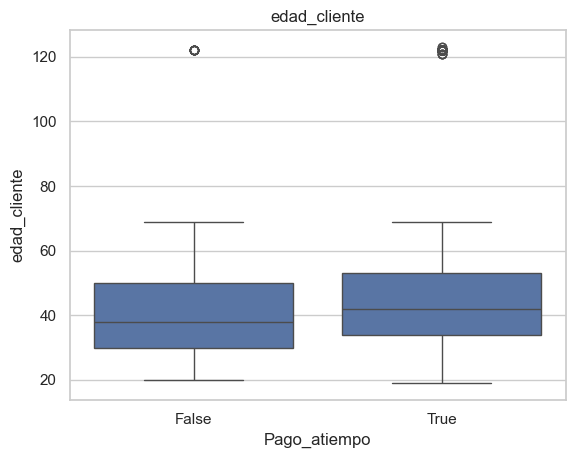

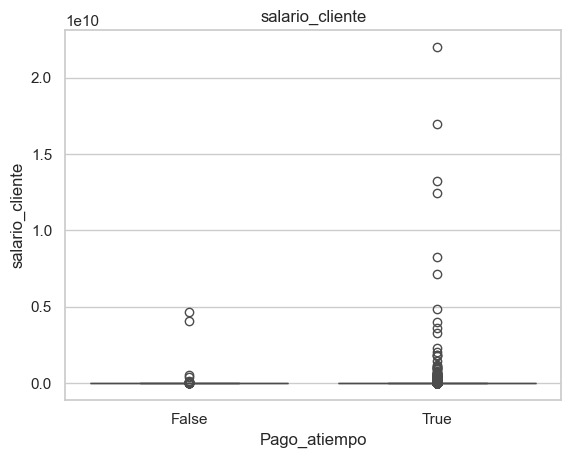

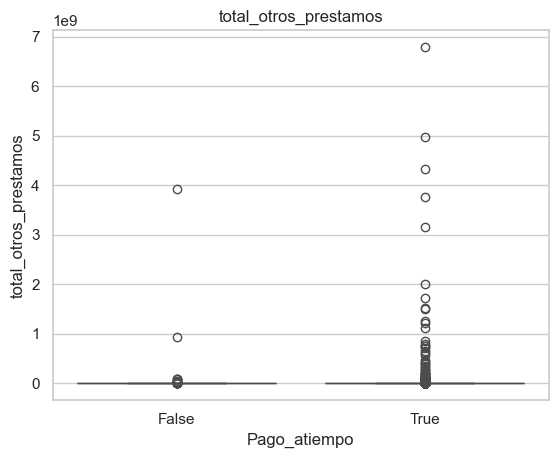

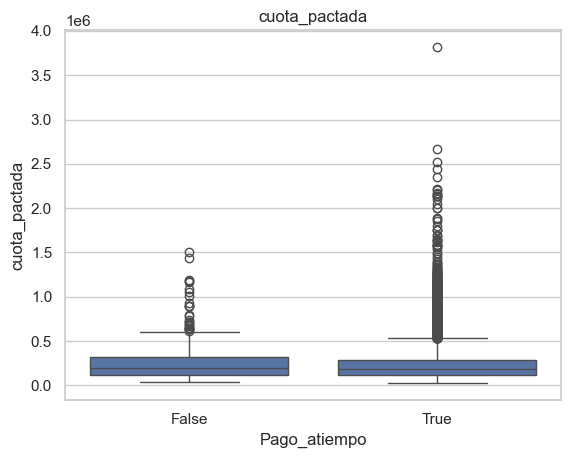

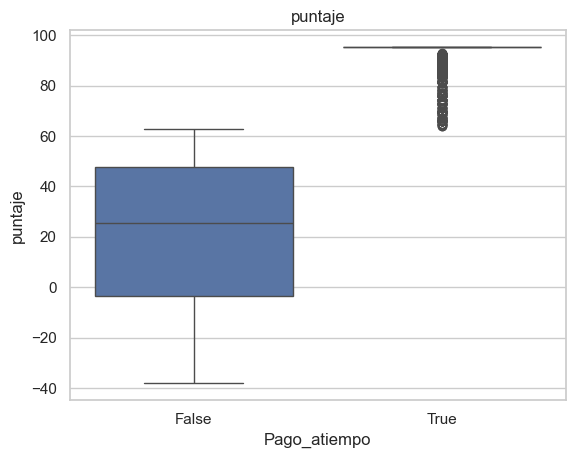

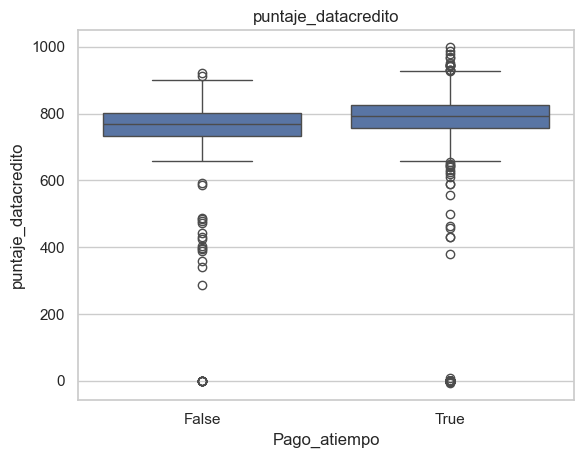

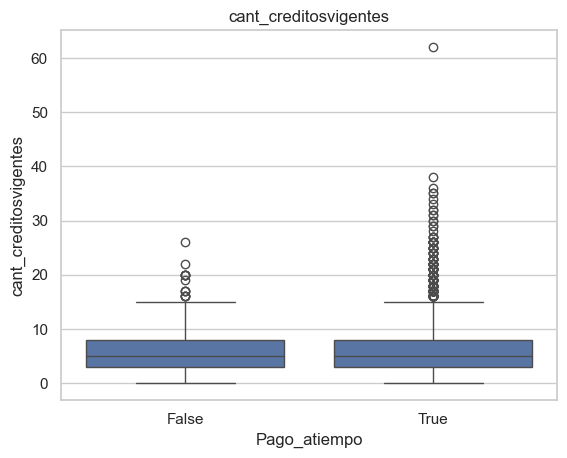

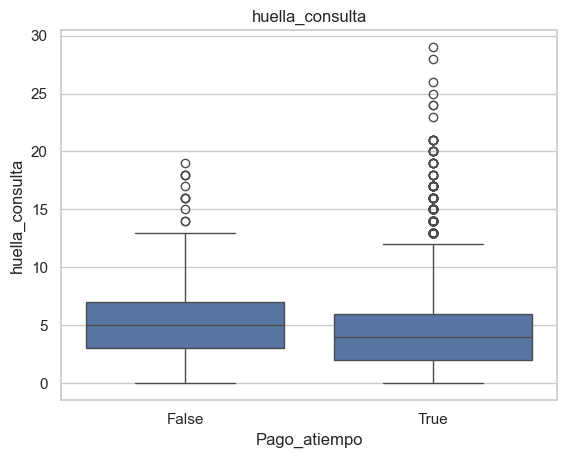

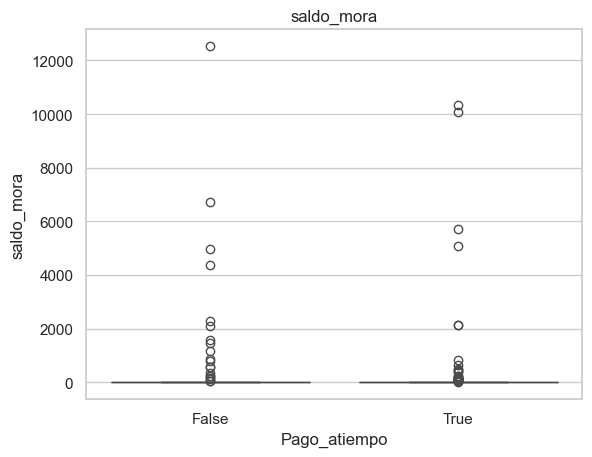

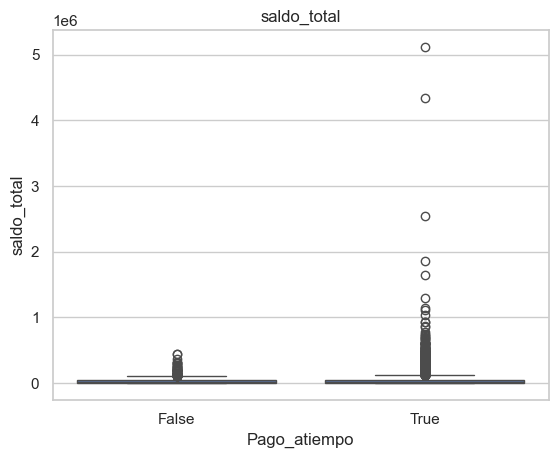

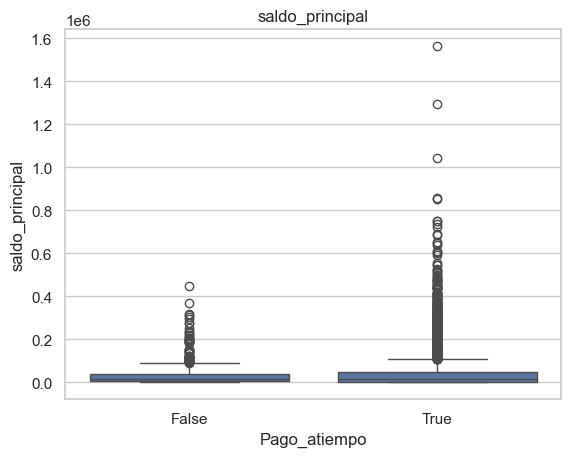

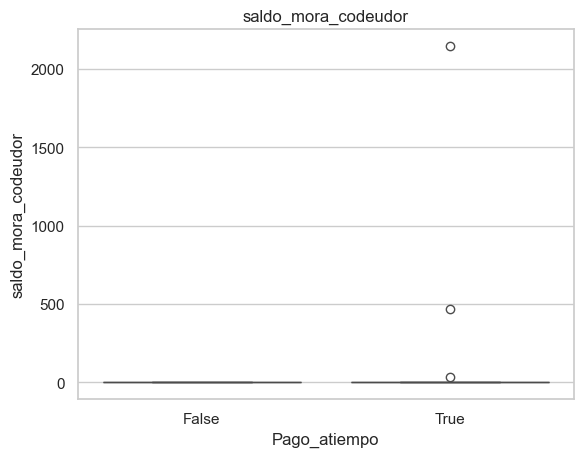

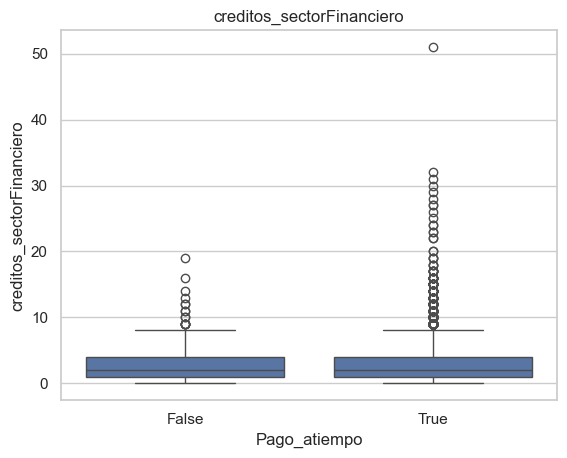

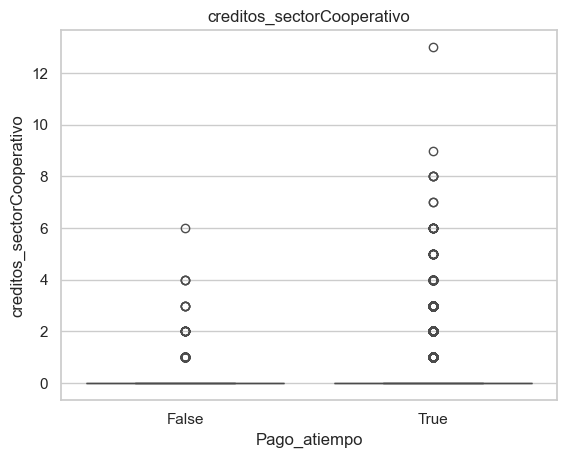

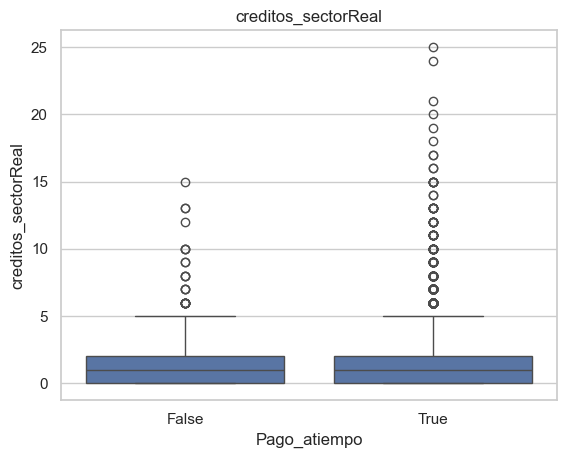

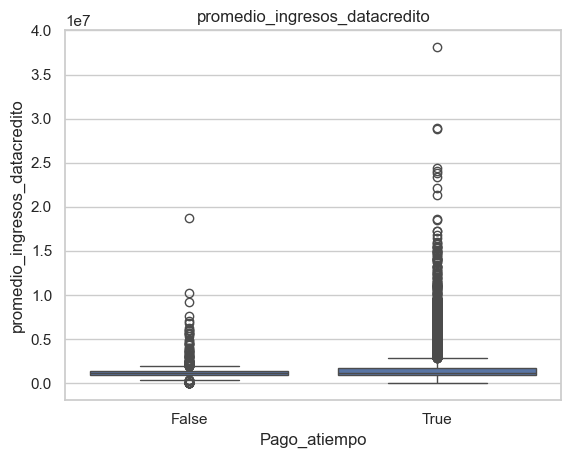

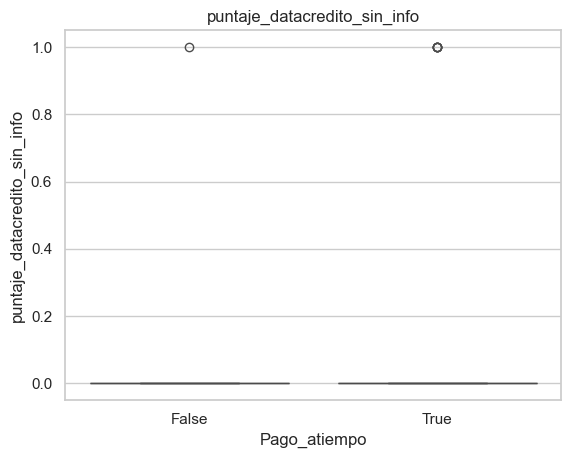

In [8]:
for col in numericas:
    sns.boxplot(x="Pago_atiempo", y=col, data=df)
    plt.title(col)
    plt.show()

- **Interpretación**

    - Variables como ingresos, puntaje o mora muestran diferencias entre clases.
    - Estas variables son candidatas fuertes para el modelo.

- **Variables categóricas vs target**:

Pago_atiempo,False,True
tipo_laboral,,
Empleado,4.293752,95.706248
Independiente,5.512597,94.487403


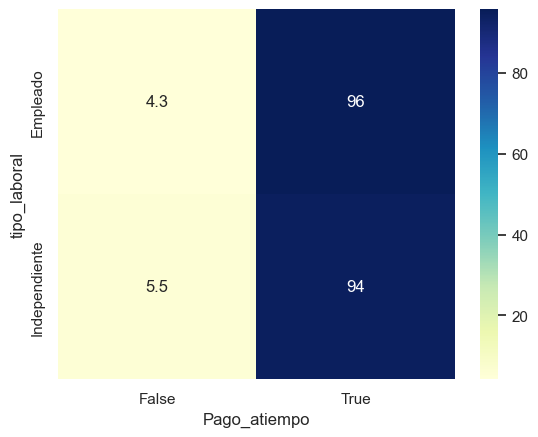

Pago_atiempo,False,True
tendencia_ingresos,,
Creciente,3.910087,96.089913
Decreciente,6.274206,93.725794
Estable,4.629630,95.370370
Desconocido,5.618729,94.381271


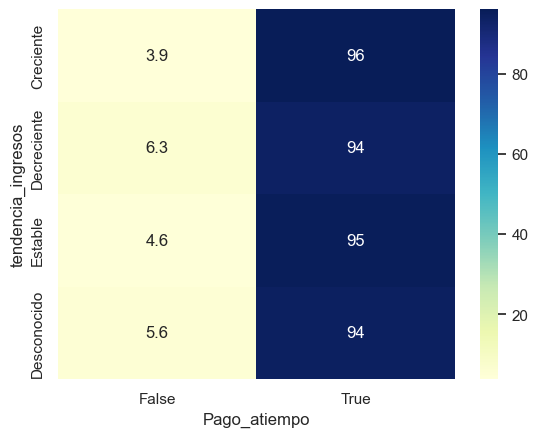

In [9]:
for col in categoricas:
    ct = pd.crosstab(df[col], df["Pago_atiempo"], normalize='index')*100
    display(ct)

    sns.heatmap(ct, annot=True, cmap="YlGnBu")
    plt.show()

- **Interpretación**

    - Algunas categorías presentan diferencias claras en tasa de pago.
    - Indican **alto poder predictivo**.

---

8. **Análisis Multivariable**

- Matriz de Correlación

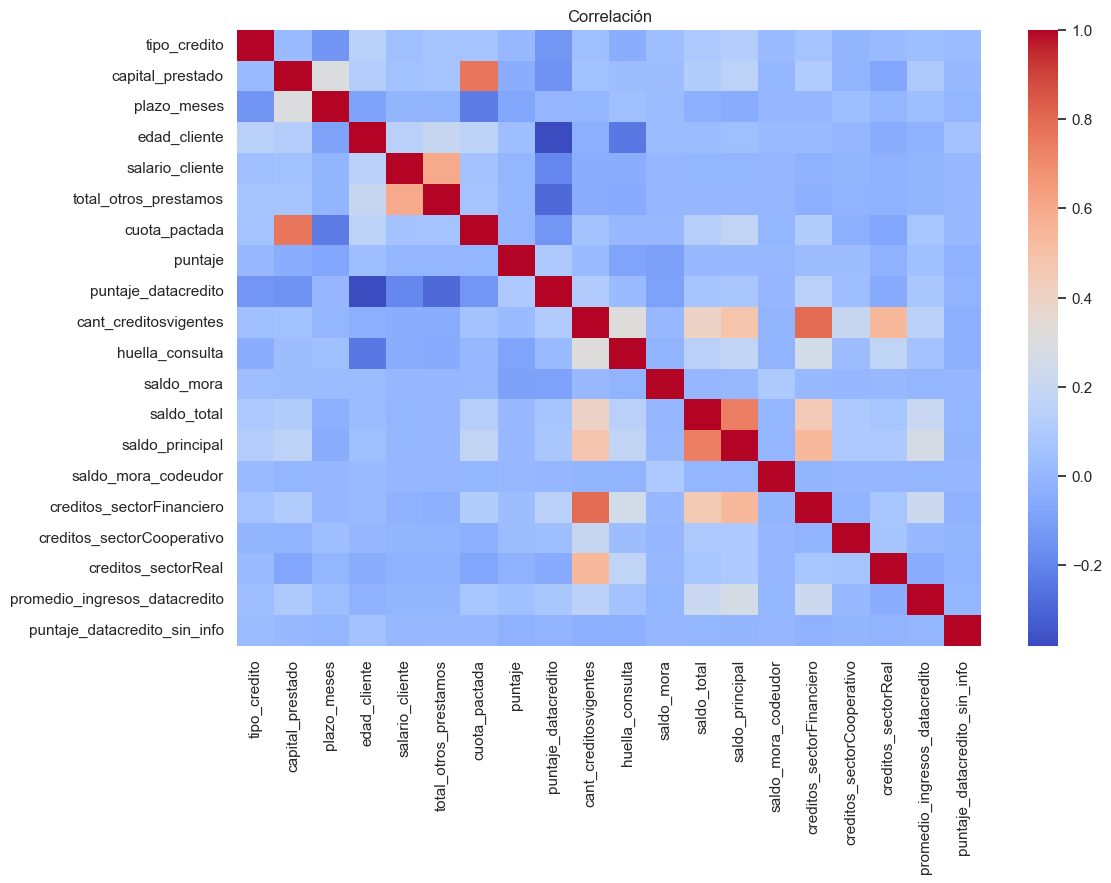

In [10]:
# Matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(df[numericas].corr(), cmap="coolwarm")
plt.title("Correlación")
plt.show()

- Pairplot

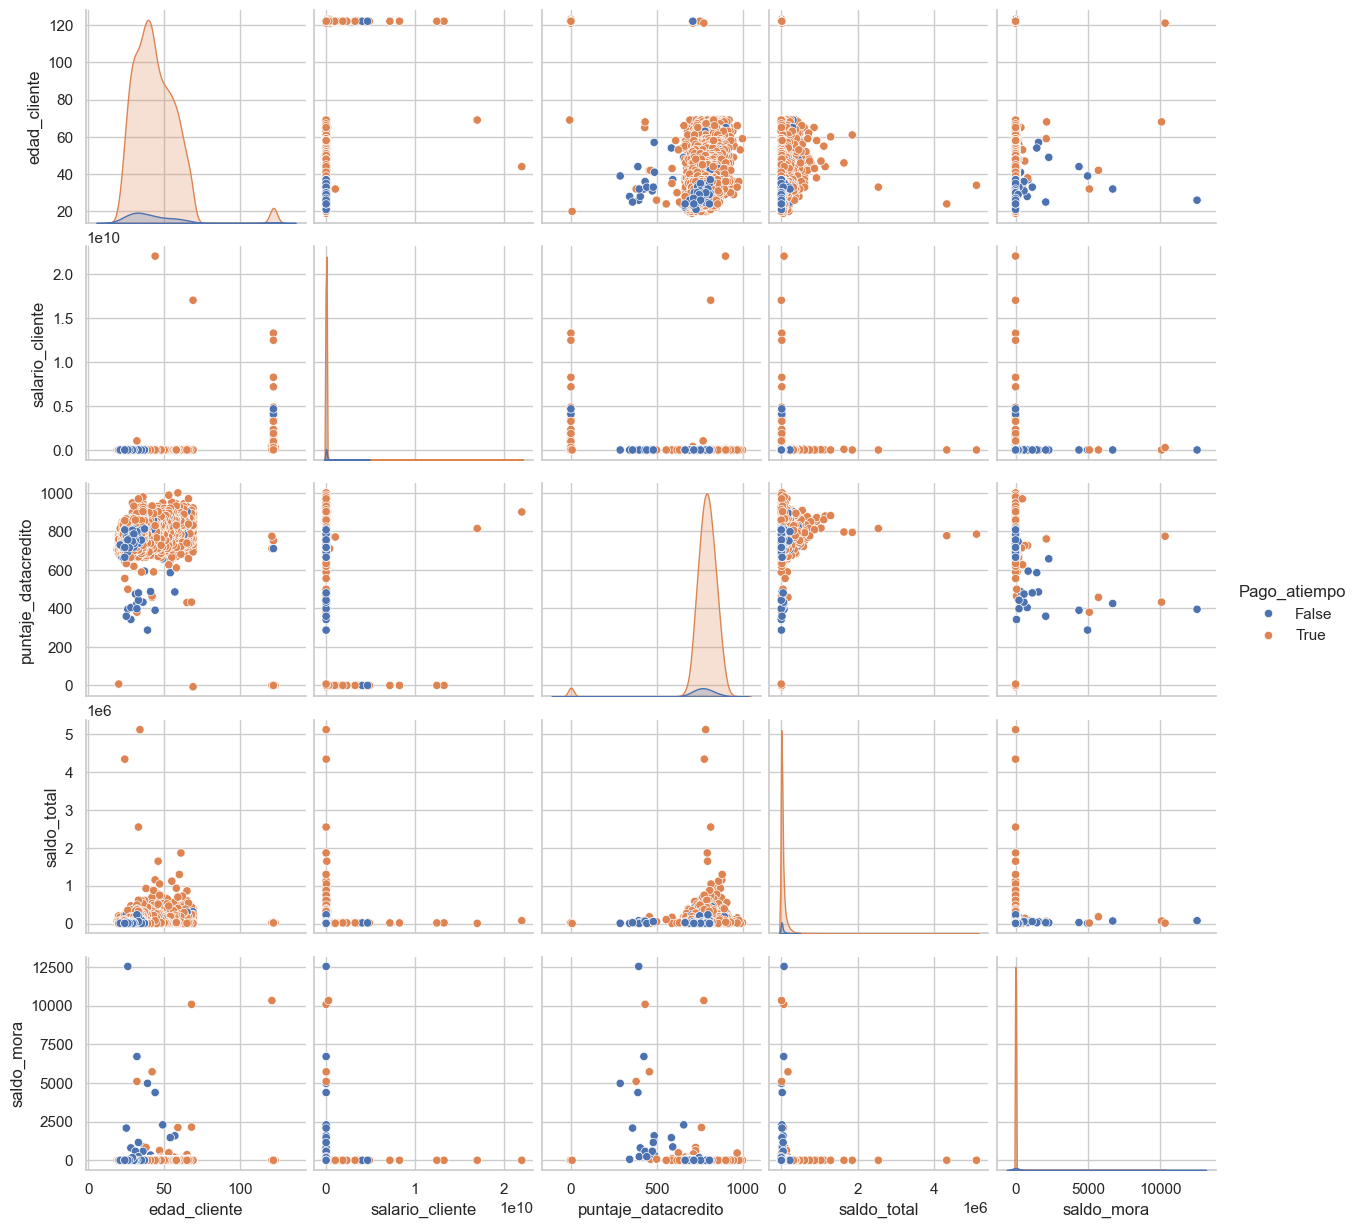

In [11]:
# Pairplot
vars_pairplot = [
    'edad_cliente',
    'salario_cliente',
    'puntaje_datacredito',
    'saldo_total',
    'saldo_mora'
]

sns.pairplot(
    df[vars_pairplot + ['Pago_atiempo']],
    hue='Pago_atiempo',
    diag_kind='kde'
)

plt.show()

---

9. **Reglas de validación**

Analizando el dataset, se llegan a las siguientes posibles reglas de validación:

- `edad_cliente` ≥ 18  

- `salario_cliente` ≥ 0  

- `capital_prestado` > 0  

- `cuota_pactada` ≥ 0  

- `Pago_atiempo` = True ó False  

- `tendencia_ingresos` = Creciente, Estable ó Decreciente

---

10. **Posibles Variables Derivadas**

Se analizaron posibles variables para un Feature Engineering potencial

- `ratio_cuota_ingreso` = cuota / salario 

- `deuda_total` = saldo_total + otros_prestamos  

- `flag_mora` = saldo_mora > 0  

- `ingreso_por_credito` = salario / creditos  

Estas variables pueden mejorar el desempeño del modelo.

---

11. **Conclusiones**

Se llega a las siguientes conclusiones:

- Dataset con fuerte componente financiero.

- Alta presencia de outliers y distribuciones sesgadas.

- Variable objetivo desbalanceada.

- Variables clave:
  - `puntaje_datacredito`
  - `saldo_mora`
  - `huella_consulta`
  
- Dataset listo para etapa de modelado.